Configuración del Entorno

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Entorno configurado correctamente.')

✅ Entorno configurado correctamente.


 Carga y Exploración Inicial de Datos

In [ ]:

# Cargar el dataset de autismo
df = pd.read_csv('autism_screening.csv')

# Renombrar la columna 'class' a 'target'
df.rename(columns={'class': 'target'}, inplace=True)

print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
print('\nPrimeras 5 filas:')
df.head()


✅ Dataset cargado: 704 registros, 21 columnas

Primeras 5 filas:


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2.0,18 and more,?,NO


 Exploración y Limpieza de Datos

In [ ]:
print('='*60)
print('INFORMACIÓN GENERAL DEL DATASET')
print('='*60)
df.info()





INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         699 non-null    int64  
 1   A2_Score         699 non-null    int64  
 2   A3_Score         699 non-null    int64  
 3   A4_Score         699 non-null    int64  
 4   A5_Score         699 non-null    int64  
 5   A6_Score         699 non-null    int64  
 6   A7_Score         699 non-null    int64  
 7   A8_Score         699 non-null    int64  
 8   A9_Score         699 non-null    int64  
 9   A10_Score        699 non-null    int64  
 10  age              697 non-null    float64
 11  gender           699 non-null    object 
 12  ethnicity        699 non-null    object 
 13  jundice          699 non-null    object 
 14  austim           699 non-null    object 
 15  contry_of_res    699 non-null    object 
 16  used_app_before  699 non-null 

In [ ]:
print('='*60)
print('1. INFORMACIÓN INICIAL DEL DATASET')
print('='*60)
print(f'Registros originales: {df.shape[0]}')
print('Valores nulos por columna:')
print(df.isnull().sum())

print('\n' + '='*60)
print('2. LIMPIEZA DE DATOS')
print('='*60)
# Eliminar duplicados
df = df.drop_duplicates()
# Eliminar filas con valores vacíos (NaN)
df = df.dropna()
print(f'Registros después de eliminar duplicados y vacíos: {df.shape[0]}')

1. INFORMACIÓN INICIAL DEL DATASET
Registros originales: 699
Valores nulos por columna:
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                2
gender             0
ethnicity          0
jundice            0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
target             0
dtype: int64

2. LIMPIEZA DE DATOS
Registros después de eliminar duplicados y vacíos: 697


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (RESULT)
Valores únicos en "result": [ 6.  5.  8.  2.  9. 10.  4.  3.  0.  1.  7.]

Distribución después de convertir a binario:
target
0    360
1    339
Name: count, dtype: int64


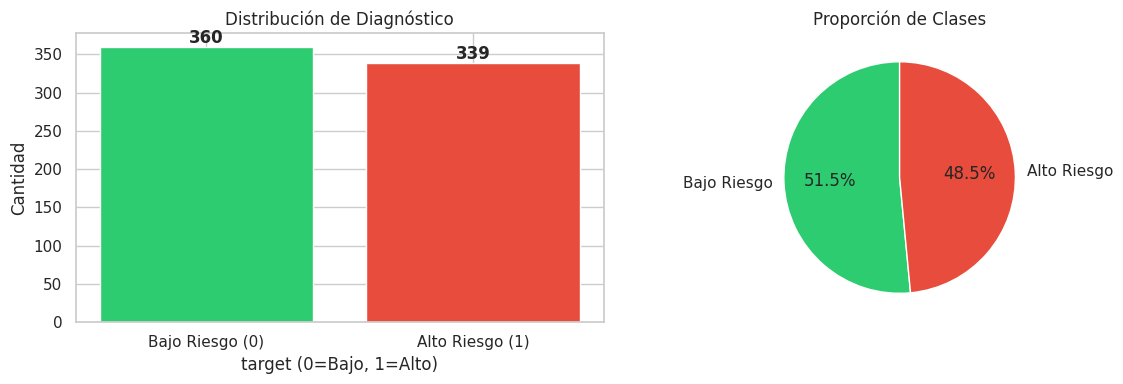

In [ ]:
print('='*60)
print('DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (RESULT)')
print('='*60)

# Verificar qué valores únicos tiene la columna 'result'
print('Valores únicos en "result":', df['result'].unique())

# Crear una columna binaria simple: 0 si result < 5, 1 si result >= 5
df['target'] = (df['result'] >= 5).astype(int)

print('\nDistribución después de convertir a binario:')
target_counts = df['target'].value_counts()
print(target_counts)

# Gráfico de distribución (versión simplificada)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

try:
    # Gráfico de barras
    axes[0].bar(['Bajo Riesgo (0)', 'Alto Riesgo (1)'], target_counts.values,
                color=['#2ecc71', '#e74c3c'])
    axes[0].set_title('Distribución de Diagnóstico')
    axes[0].set_xlabel('target (0=Bajo, 1=Alto)')
    axes[0].set_ylabel('Cantidad')

    # Agregar números sobre las barras
    for i, v in enumerate(target_counts.values):
        axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

    # Gráfico de pastel
    axes[1].pie(target_counts.values, labels=['Bajo Riesgo', 'Alto Riesgo'],
                autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
    axes[1].set_title('Proporción de Clases')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'\n Error en gráficos: {e}')
    print('Pero los datos están listos. Continuemos.')

-Distribución de variables numéricas clave -Mapeo de nombres originales a nombres genéricos de OpenML

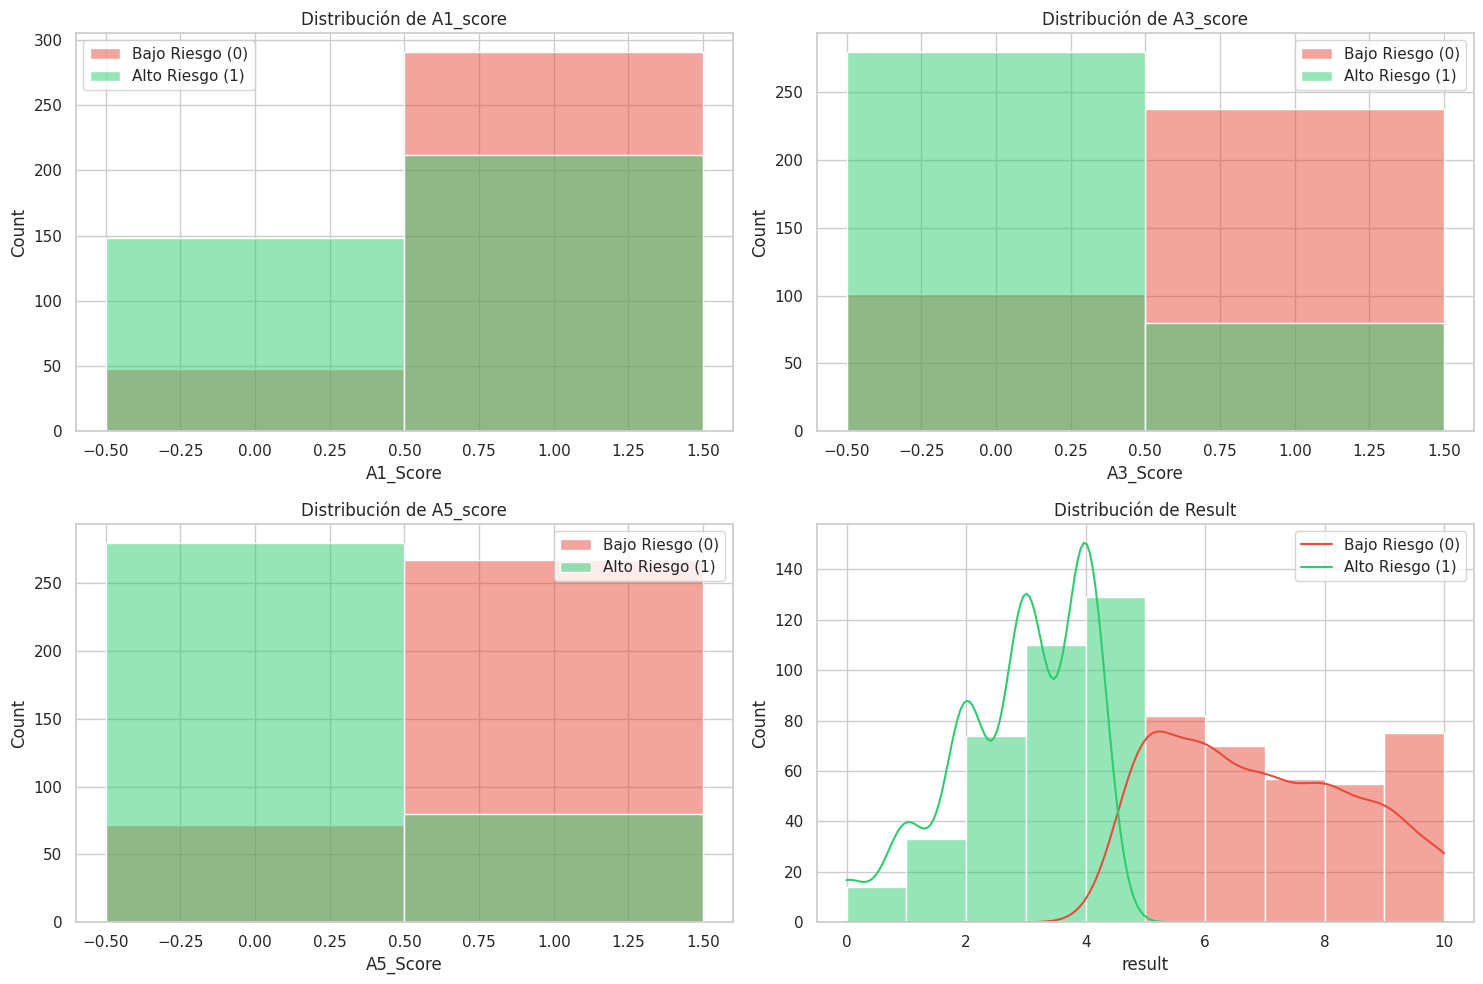

In [ ]:
# Variables a graficar: usamos 'result' y algunas preguntas individuales
# 'result' va de 0 a 10, por eso se verá más suave
cols_to_plot = ['A1_Score', 'A3_Score', 'A5_Score', 'result']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    if col == 'result':
        # Para 'result' usamos más bins y KDE (se verá como el de billetes)
        sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax,
                     bins=10, palette=['#2ecc71', '#e74c3c'])
    else:
        # Para las preguntas individuales (0 o 1) usamos menos bins
        sns.histplot(data=df, x=col, hue='target', kde=False, ax=ax,
                     bins=[-0.5, 0.5, 1.5], palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'Distribución de {col.capitalize()}')
    ax.legend(['Bajo Riesgo (0)', 'Alto Riesgo (1)'])

plt.tight_layout()
plt.show()

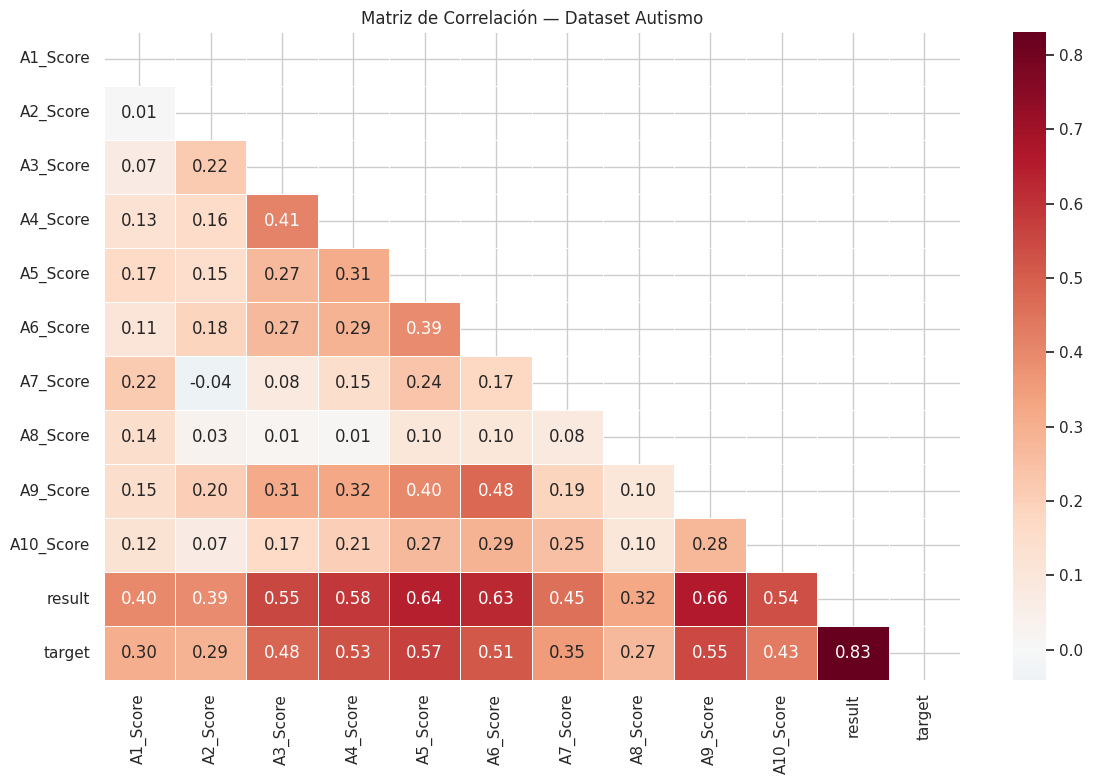

Matriz de correlación generada.


In [ ]:
# Seleccionamos solo las columnas numéricas para que el gráfico sea claro
num_cols = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
            'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score',
            'result', 'target']

plt.figure(figsize=(12, 8))

# Calcular la correlación solo de estas columnas
corr = df[num_cols].corr()

# Crear una máscara para ocultar la mitad superior del triángulo (se ve más limpio)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Dibujar el mapa de calor
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5)
plt.title('Matriz de Correlación — Dataset Autismo')
plt.tight_layout()
plt.show()

print('Matriz de correlación generada.')

Preparación de Datos para el Modelado

In [ ]:
print('='*60)
print('PREPARACIÓN DE DATOS PARA EL MODELADO')
print('='*60)

# 1. Eliminar columnas que no sirven para predecir (IDs, descripciones, y el 'result' original)
columnas_a_eliminar = ['result', 'age_desc', 'relation', 'ID']
cols_existentes = [col for col in columnas_a_eliminar if col in df.columns]
df_limpio = df.drop(columns=cols_existentes)

# 2. Convertir texto a números (One-Hot Encoding)
# Transforma "gender: Male/Female" en columnas numéricas "gender_Male: 0/1"
df_numerico = pd.get_dummies(df_limpio, drop_first=True, dtype=int)

# 3. Separar características (X) y objetivo (y)
X = df_numerico.drop(columns='target')
y = df_numerico['target']

print(f'✅ Datos transformados exitosamente.')
print(f'   - Características (X): {X.shape[1]} columnas numéricas')
print(f'   - Objetivo (y): {y.shape[0]} registros')

# 4. División en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\nDatos de Entrenamiento: {X_train.shape[0]} muestras')
print(f'Datos de Prueba:        {X_test.shape[0]} muestras')

PREPARACIÓN DE DATOS PARA EL MODELADO
✅ Datos transformados exitosamente.
   - Características (X): 93 columnas numéricas
   - Objetivo (y): 697 registros

Datos de Entrenamiento: 557 muestras
Datos de Prueba:        140 muestras


Entrenamiento y Comparación de Modelos

Evaluando modelos con Validación Cruzada (5-fold):
--------------------------------------------------
LogisticRegression         Accuracy: 0.9839 ± 0.0153
DecisionTree               Accuracy: 0.8134 ± 0.0201
RandomForest               Accuracy: 0.8905 ± 0.0106


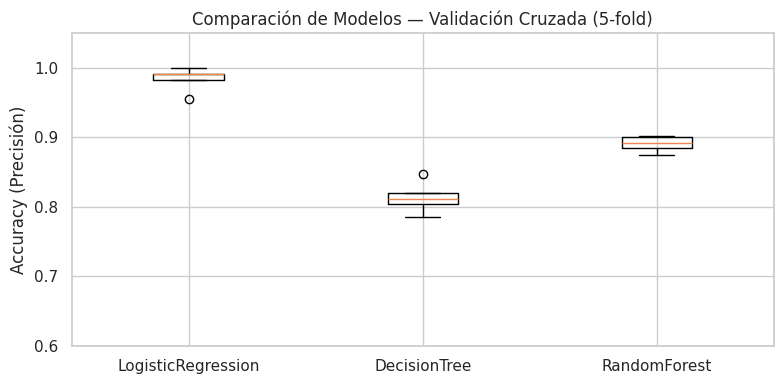

In [ ]:
# 1. Definición de los "Pipelines" (Flujos de trabajo)
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
    ])
}

# 2. Entrenamiento y Validación Cruzada (5-fold)
results = {}
print("Evaluando modelos con Validación Cruzada (5-fold):")
print("-" * 50)

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

# 3. Comparación visual de los resultados
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (Precisión)')
ax.set_title('Comparación de Modelos — Validación Cruzada (5-fold)')
ax.set_ylim(0.6, 1.05)  # Ajuste visual para ver mejor las diferencias
plt.tight_layout()
plt.show()

Evaluación del mejor modelo

In [ ]:
# 1. Seleccionar el mejor modelo según el promedio de la validación cruzada
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]

# Entrenar el mejor modelo con TODOS los datos de entrenamiento
best_pipeline.fit(X_train, y_train)

# Hacer predicciones sobre el conjunto de prueba (datos nunca vistos)
y_pred = best_pipeline.predict(X_test)

print(f' Mejor modelo seleccionado: {best_name}')
print(f' Accuracy en datos de prueba (Test): {best_pipeline.score(X_test, y_test):.4f}')

print('\n' + '='*60)
print('REPORTE DE CLASIFICACIÓN')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Bajo Riesgo (0)', 'Alto Riesgo (1)']))




 Mejor modelo seleccionado: LogisticRegression
 Accuracy en datos de prueba (Test): 0.9857

REPORTE DE CLASIFICACIÓN
                 precision    recall  f1-score   support

Bajo Riesgo (0)       0.97      1.00      0.99        72
Alto Riesgo (1)       1.00      0.97      0.99        68

       accuracy                           0.99       140
      macro avg       0.99      0.99      0.99       140
   weighted avg       0.99      0.99      0.99       140



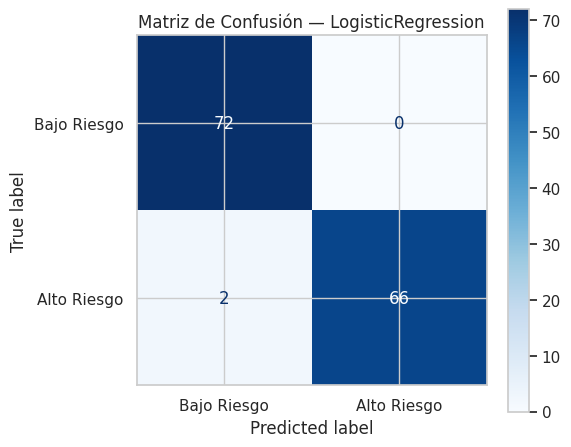

In [ ]:
# 2. Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Bajo Riesgo', 'Alto Riesgo'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()



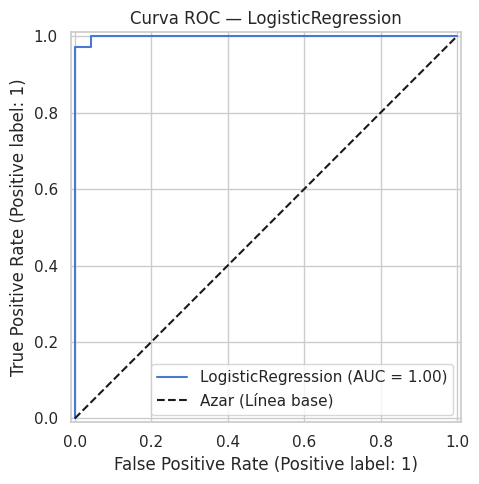

In [ ]:
# 3. Curva ROC (Mide la capacidad del modelo para distinguir entre clases)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Azar (Línea base)')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

Serialización y Despliegue Conceptual

In [ ]:
# 1. Guardar el modelo entrenado (Serialización)
MODEL_PATH = 'modelo_autismo.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f' Modelo guardado exitosamente en: {MODEL_PATH}')

# 2. Cargar y verificar el modelo
modelo_cargado = joblib.load(MODEL_PATH)
print(' Modelo cargado y listo para usar.\n')

# 3. Simulación de predicción con un caso de prueba
# Tomamos un paciente real de nuestros datos de prueba para asegurar que funcione
caso_ejemplo = X_test.iloc[0:1]
valor_real = y_test.iloc[0]

# El modelo hace su predicción
prediccion = modelo_cargado.predict(caso_ejemplo)[0]
probabilidades = modelo_cargado.predict_proba(caso_ejemplo)[0]

print('='*55)
print('🔍 RESULTADO DE INFERENCIA (SIMULACIÓN DE CONSULTA)')
print('='*55)
print(f'Diagnóstico real del paciente:  {"Alto Riesgo (1)" if valor_real == 1 else "Bajo Riesgo (0)"}')
print(f'Predicción de la IA:            {"Alto Riesgo (1) " if prediccion == 1 else "Bajo Riesgo (0) "}')
print('-' * 55)
print(f'Confianza en Bajo Riesgo (0):   {probabilidades[0]*100:.2f}%')
print(f'Confianza en Alto Riesgo (1):   {probabilidades[1]*100:.2f}%')
print('='*55)

 Modelo guardado exitosamente en: modelo_autismo.joblib
 Modelo cargado y listo para usar.

🔍 RESULTADO DE INFERENCIA (SIMULACIÓN DE CONSULTA)
Diagnóstico real del paciente:  Bajo Riesgo (0)
Predicción de la IA:            Bajo Riesgo (0) 
-------------------------------------------------------
Confianza en Bajo Riesgo (0):   86.52%
Confianza en Alto Riesgo (1):   13.48%
